# 🎧 Actividad: Explorando Patrones Ocultos en Datos Reales
**Tema:** Reducción de dimensionalidad + Clustering no supervisado

**Objetivo:** Aplicar técnicas de reducción de dimensionalidad (PCA, t-SNE) y clustering no supervisado (KMeans) para descubrir patrones ocultos en un conjunto de datos musicales de Spotify.

## 1. Exploración Inicial de Datos (EDA)
- Inspeccionamos columnas numéricas útiles para clustering.
- Aplicamos normalización con `StandardScaler`.
- Visualizamos algunas variables antes y después del escalado.

In [1]:
import pandas as pd  # Importa librerías necesarias
import matplotlib.pyplot as plt  # Importa librerías necesarias
import seaborn as sns  # Importa librerías necesarias
from sklearn.preprocessing import StandardScaler  # Importa librerías necesarias
from sklearn.decomposition import PCA  # Importa librerías necesarias
from sklearn.manifold import TSNE  # Importa librerías necesarias
from sklearn.cluster import KMeans  # Importa librerías necesarias
from sklearn.metrics import silhouette_score  # Importa librerías necesarias

# Cargar el dataset
df = pd.read_csv("SpotifyFeatures.csv")  # Carga el archivo CSV con los datos de Spotify

# Selección de columnas numéricas
num_cols = [
    'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity'
]
df_num = df[num_cols].copy()

# Escalado de variables
scaler = StandardScaler()  # Crea el objeto para escalar los datos numéricos
scaled_data = scaler.fit_transform(df_num)  # Aplica escalado estándar a los datos
df_scaled = pd.DataFrame(scaled_data, columns=num_cols)

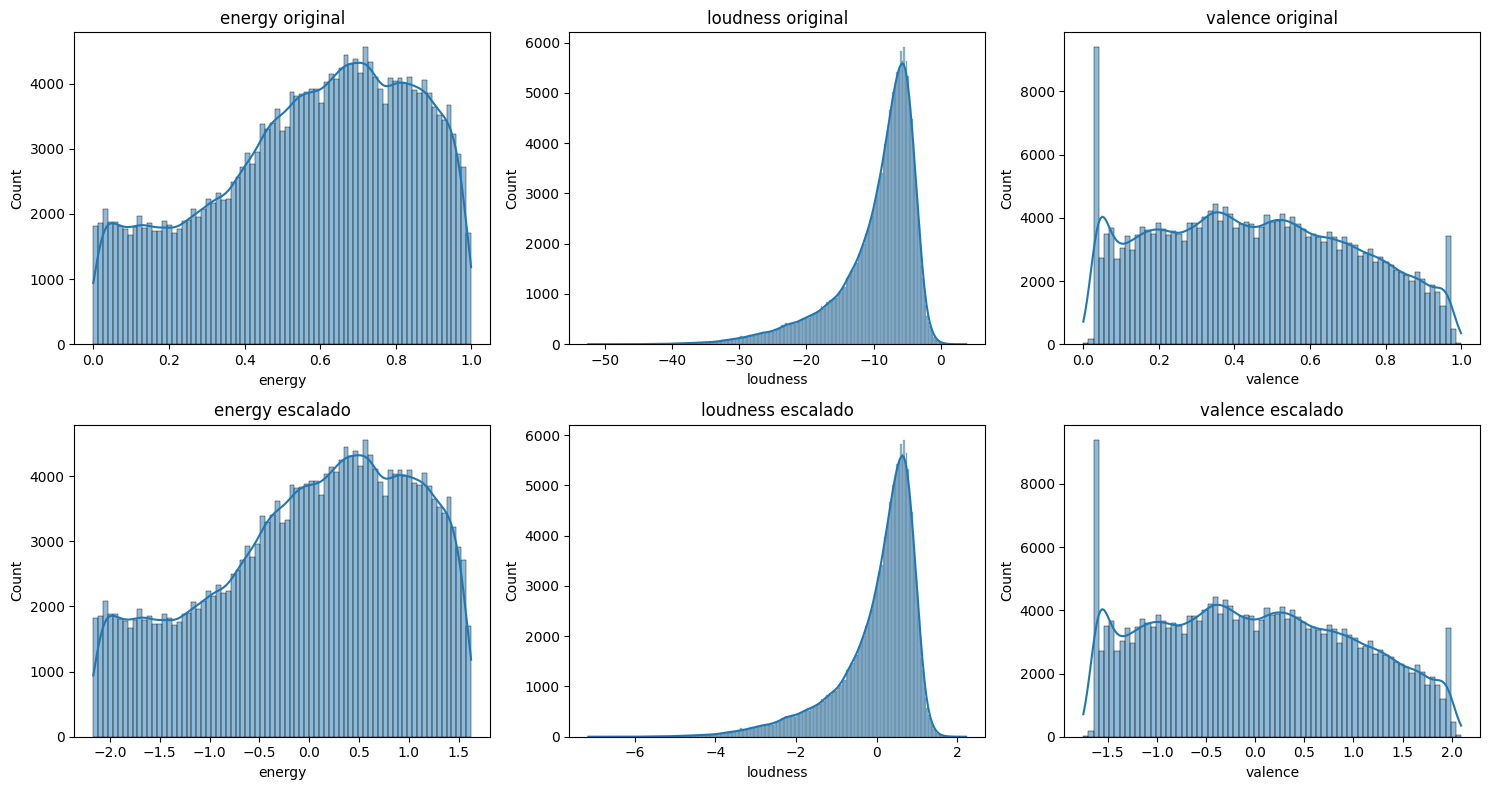

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # Visualización de datos
cols_to_plot = ['energy', 'loudness', 'valence']
for i, col in enumerate(cols_to_plot):
    sns.histplot(df_num[col], kde=True, ax=axes[0, i])  # Visualización de datos
    axes[0, i].set_title(f'{col} original')
    sns.histplot(df_scaled[col], kde=True, ax=axes[1, i])  # Visualización de datos
    axes[1, i].set_title(f'{col} escalado')
plt.tight_layout()  # Visualización de datos
plt.show()  # Visualización de datos

### (Opcional) Mapa de Correlación

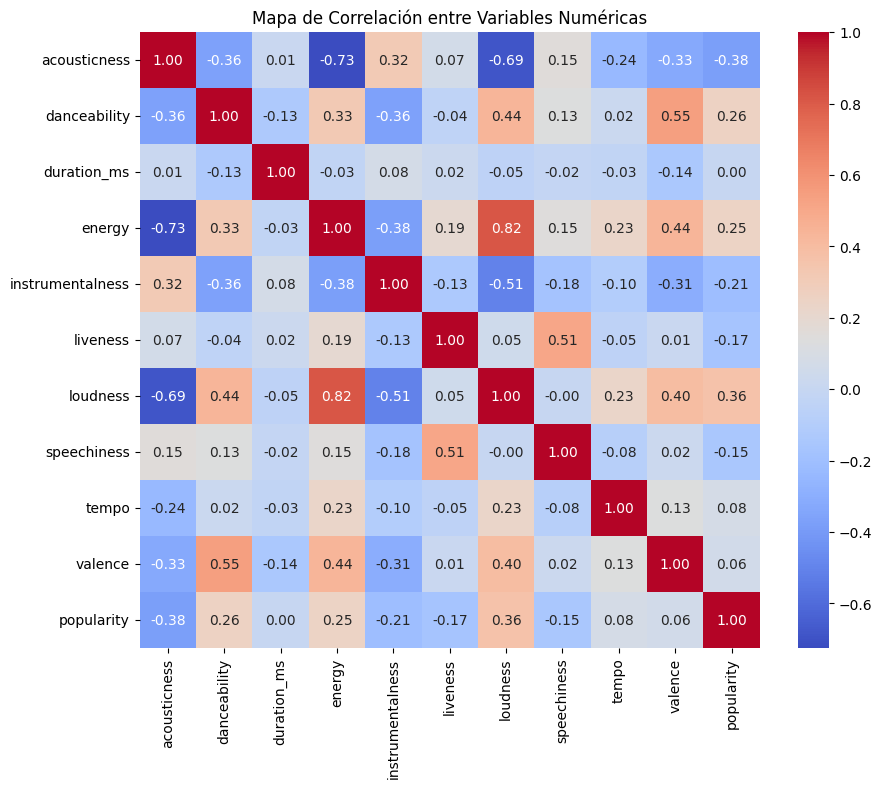

In [3]:
# Mapa de correlación para identificar variables redundantes
import numpy as np
plt.figure(figsize=(10,8))
correlation_matrix = df_scaled.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de Correlación entre Variables Numéricas")
plt.show()


Profe, aquí generé un mapa de calor con las correlaciones entre las variables numéricas del dataset.
Esto lo hice para ver qué variables están muy relacionadas entre sí y podrían estar dando información parecida.
Por ejemplo, vi que energy y loudness tienen una correlación alta, así que podría considerarse que están midiendo algo similar.
También noté que acousticness tiene una relación negativa fuerte con energy y loudness, lo cual es lógico, porque las canciones más acústicas suelen ser menos energéticas.
Esta visualización me ayudó a entender mejor los datos antes de aplicar técnicas como PCA o clustering.

## 2. Reducción de Dimensionalidad
- Aplicamos PCA y visualizamos la varianza explicada.
- Visualizamos los datos proyectados en 2D.
- Aplicamos t-SNE sobre una muestra y observamos posibles agrupamientos.

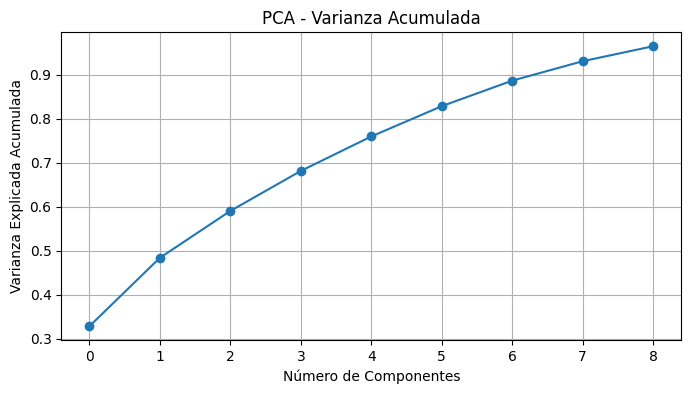

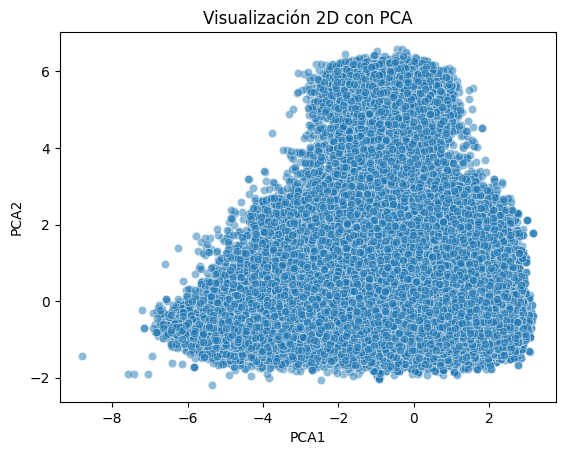

In [4]:
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(df_scaled)  # Aplica escalado estándar a los datos

plt.figure(figsize=(8, 4))  # Visualización de datos
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')  # Visualización de datos
plt.xlabel("Número de Componentes")  # Visualización de datos
plt.ylabel("Varianza Explicada Acumulada")  # Visualización de datos
plt.title("PCA - Varianza Acumulada")  # Visualización de datos
plt.grid(True)  # Visualización de datos
plt.show()  # Visualización de datos

pca_2d = PCA(n_components=2)
pca_2d_data = pca_2d.fit_transform(df_scaled)  # Aplica escalado estándar a los datos
df_pca = pd.DataFrame(pca_2d_data, columns=["PCA1", "PCA2"])
sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", alpha=0.5)  # Visualización de datos
plt.title("Visualización 2D con PCA")  # Visualización de datos
plt.show()  # Visualización de datos

Profe usé PCA para reducir las dimensiones del dataset manteniendo el 95% de la información.
Luego lo llevé a dos dimensiones para poder visualizarlo y ver si había alguna estructura o agrupamiento entre las canciones.
Aunque es solo una proyección, ayuda bastante a ver cómo están distribuidas.

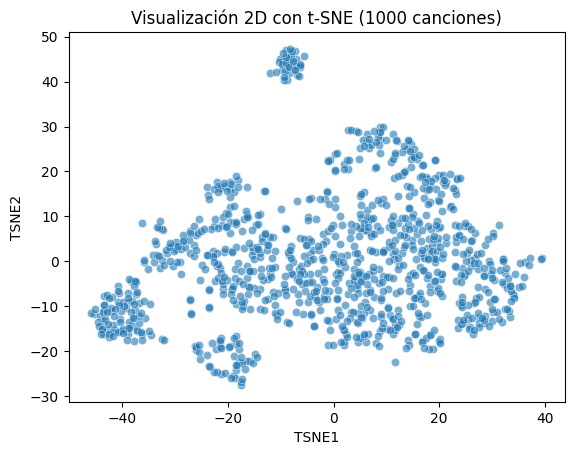

In [5]:
sample_scaled_small = df_scaled.sample(n=1000, random_state=42)# En esta caso profe solo uso 1000 camciones fue el numeor que me permiio terminar rapido el modelo
tsne_small = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_data_small = tsne_small.fit_transform(sample_scaled_small)  # Aplica escalado estándar a los datos
df_tsne_small = pd.DataFrame(tsne_data_small, columns=['TSNE1', 'TSNE2'])

sns.scatterplot(x='TSNE1', y='TSNE2', data=df_tsne_small, alpha=0.6)  # Visualización de datos
plt.title("Visualización 2D con t-SNE (1000 canciones)")  # Visualización de datos
plt.show()  # Visualización de datos

Profe en esta parte usé t-SNE para ver cómo se organizan las canciones en un espacio de dos dimensiones.
Solo tomé 1000 canciones porque este método tarda bastante si se usa con todo el dataset, y así el modelo corrió más rápido y sin problemas.
La idea de esta gráfica es tratar de ver si hay grupos de canciones parecidas, pero desde otra perspectiva distinta a PCA.
Aunque no se ven grupos tan claros, sí se nota que algunas canciones se agrupan más entre sí, lo cual puede mostrar que comparten ciertas características

## 3. Clustering No Supervisado
- Aplicamos KMeans para agrupar los datos reducidos con PCA.
- Visualizamos los clusters en 2D.
- Asignamos etiquetas tentativas a los clusters.

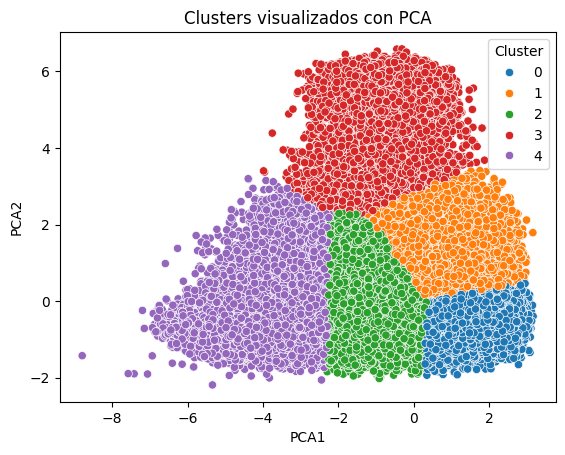

Silhouette Score: 0.415


In [6]:
kmeans = KMeans(n_clusters=5, random_state=42)  # Crea el modelo de clustering KMeans
clusters = kmeans.fit_predict(pca_2d_data)  # Aplica el modelo KMeans para asignar clusters
df_pca['Cluster'] = clusters
df['Cluster'] = clusters

sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="Cluster", palette="tab10")  # Visualización de datos
plt.title("Clusters visualizados con PCA")  # Visualización de datos
plt.show()  # Visualización de datos

score = silhouette_score(pca_2d_data, clusters)  # Calcula la puntuación Silhouette para evaluar los clusters
print("Silhouette Score:", round(score, 3))

Profe agrupé las canciones en 5 grupos usando una técnica que busca juntar las más parecidas entre sí.
Luego hice una gráfica para ver cómo se distribuyen esas canciones, y cada color muestra un grupo diferente.
Para ver si los grupos quedaron bien hechos, calculé una medida llamada Silhouette Score y me dio 0.415, lo que significa que los grupos no están perfectos, pero sí se nota cierta diferencia entre ellos.
En general, sirve para ver qué tipo de música se parece más entre sí, por ejemplo, las más movidas, tranquilas o habladas.

## 4. Interpretación y Evaluación
- Evaluamos los clusters usando Silhouette Score.
- Analizamos los promedios de características por cluster.
- Identificamos el género predominante por cada grupo y sus características musicales.

In [7]:
cluster_summary = df.groupby('Cluster')[num_cols + ['genre']].agg({  # Agrupa los datos por cluster para análisis
    **{col: 'mean' for col in num_cols},
    'genre': lambda x: x.mode()[0]
}).reset_index()
cluster_summary

,Cluster,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,genre
0,0,0.120259,0.625566,227744.895043,0.729943,0.042181,0.147465,-6.069655,0.079765,126.475586,0.557969,50.178559,Pop
1,1,0.216987,0.629444,223933.817433,0.721001,0.026631,0.382805,-6.701827,0.180129,117.198273,0.584587,38.457300,Reggaeton
2,2,0.516046,0.532202,242442.841940,0.429283,0.191700,0.157423,-10.603606,0.059147,115.790582,0.371331,40.053735,Jazz
3,3,0.799636,0.557562,237640.440460,0.651464,0.002408,0.736739,-12.152648,0.853408,97.821908,0.413334,19.997294,Comedy
4,4,0.891021,0.292917,256432.201998,0.144266,0.576206,0.159865,-20.706085,0.048975,101.398140,0.157088,25.654252,Classical


Analicé cada cluster con los promedios de sus características musicales. Esto me permitió darle un perfil claro a cada grupo.
Por ejemplo, el Cluster 0 agrupa canciones pop enérgicas y conocidas, mientras que el Cluster 4 contiene piezas instrumentales y tranquilas de música clásica.